# ChatBot @ `Multi-Tool`
powred by `LangGraph`

In [1]:
# Getting tools onboard

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
# Defining Arxiv component (Tool #1)
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv papers")
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
# Defining Wikipedia component (Tool #2)
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki, description="Query Wiki papers / articles")
print(wiki.name)

wikipedia


In [5]:
wiki.invoke("OpenAI ChatGPT")

'Page: ChatGPT\nSummary: ChatGPT is a generative artificial intelligence chatbot developed by OpenAI. It was released in November 2022. It uses large language models—specifically generative pre-trained transformers (GPTs)—to generate text, speech, and images in response to user prompts. It is credited with accelerating the AI boom, an ongoing period marked by rapid investment and public attention toward the field of artificial intelligence (AI). OpenAI operates the service on a freemium model. Use'

In [6]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [7]:
# Tavily Search Tool (Tool #3)
 
from langchain_community.tools.tavily_search import  TavilySearchResults

tavily = TavilySearchResults()

/var/folders/mb/n07mq38j10x93x8ln22q2h180000gn/T/ipykernel_13516/4168830913.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [8]:
tavily.invoke("What is new in Agentic AI today ?")

[{'title': 'Agentic AI News: What Enterprise Leaders Must Understand About Autonomous AI in 2026',
  'url': 'https://www.linkedin.com/pulse/agentic-ai-news-what-enterprise-leaders-must-understand-autonomous-mo59c',
  'content': 'Agentic AI News Signals a New Era of Enterprise AI The biggest insight emerging from agentic AI news in 2026 is simple but powerful: the winners will not be the companies that adopt AI the fastest. They will be the companies that orchestrate, govern, and scale autonomous systems effectively.\n\nAgentic AI introduces a completely new operating model. Instead of isolated tools, businesses are deploying intelligent agents that collaborate through multi-agent systems, operate as part of hybrid human and AI teams, and execute complex workflows with minimal supervision. In this environment, governance, reliability, and trust become true competitive advantages. [...] The result is a new layer of AI-powered enterprise automation. Instead of automating individual tasks,

In [9]:
# Combining tools in a list

tools = [arxiv, wiki, tavily]

In [10]:
# Initializing the LLM Model

from langchain_groq import ChatGroq
llm = ChatGroq(model = "llama-3.1-8b-instant")

In [11]:
llm.invoke("What is MCP Server ?")

AIMessage(content='MCP (Minecraft Protocol) Server is a server software that enables Minecraft players to connect to and play on a Minecraft game server. It\'s a crucial component for hosting Minecraft multiplayer servers, allowing players to join, interact, and play together in a shared game world.\n\nMCP Server is often used by Minecraft server administrators (often referred to as "server owners" or "admins") to create and manage their own custom Minecraft servers. These servers can be public, allowing anyone to join, or private, where access is restricted to a specific group of players.\n\nSome key features of an MCP Server include:\n\n1. **Multiplayer support**: Allows multiple players to join and play together in a shared game world.\n2. **Game mode management**: Server owners can configure the game mode (e.g., Survival, Creative, Hardcore) and set various rules and settings.\n3. **World management**: Admins can create, edit, and delete worlds, as well as configure world settings,

In [12]:
llm_with_tools = llm.bind_tools(tools) # Binding tools created above

In [13]:
# Executing call

llm_with_tools.invoke("What is the latest advancements in Agentic AI and Voice ?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'r1ed8w09w', 'function': {'arguments': '{"query":"Agentic AI and Voice latest advancements"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': '32xeq9zgy', 'function': {'arguments': '{"query":"Agentic AI 2024"}', 'name': 'wikipedia'}, 'type': 'function'}, {'id': 'c9grvjbg3', 'function': {'arguments': '{"query":"Voice AI advancements 2024"}', 'name': 'wikipedia'}, 'type': 'function'}, {'id': '9w163qdk6', 'function': {'arguments': '{"query":"Agentic AI 2024"}', 'name': 'arxiv'}, 'type': 'function'}, {'id': '201bq2nv5', 'function': {'arguments': '{"query":"Voice AI advancements"}', 'name': 'arxiv'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 403, 'total_tokens': 498, 'completion_time': 0.116231011, 'completion_tokens_details': None, 'prompt_time': 0.030525311, 'prompt_tokens_details': None, 'queue_time': 0.061028219, 'total_time': 0.146756322}, 'model_

In [14]:
llm_with_tools.invoke("What is the latest research in Quantum Computing ?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '31x5rzydg', 'function': {'arguments': '{"query":"Quantum Computing Research 2024"}', 'name': 'arxiv'}, 'type': 'function'}, {'id': '7bv9q16r6', 'function': {'arguments': '{"query":"Quantum Computing Latest Research"}', 'name': 'wikipedia'}, 'type': 'function'}, {'id': 'ekxsc8ggp', 'function': {'arguments': '{"query":"latest research in quantum computing"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 400, 'total_tokens': 459, 'completion_time': 0.085141376, 'completion_tokens_details': None, 'prompt_time': 0.023956636, 'prompt_tokens_details': None, 'queue_time': 0.060749052, 'total_time': 0.109098012}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df54d-f1d1-7ee2-889f-e0ecf182c453

In [15]:
llm_with_tools.invoke("What is Deep Learning ?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'tpavdp8dq', 'function': {'arguments': '{"query":"Deep learning"}', 'name': 'wikipedia'}, 'type': 'function'}, {'id': '5475x2ts5', 'function': {'arguments': '{"query":"Deep learning"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 396, 'total_tokens': 429, 'completion_time': 0.049204601, 'completion_tokens_details': None, 'prompt_time': 0.068409098, 'prompt_tokens_details': None, 'queue_time': 0.061567619, 'total_time': 0.117613699}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df54d-f2dc-7c52-bb79-ffb2d9482b0f-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'Deep learning'}, 'id': 'tpavdp8dq', 'type': 'tool_call'}, {'name': 'tavily_search_results_json', 'args': {'query': 'D

<br>

## Creating The LangGraph Application (Workflow)

### State Schema

In [16]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage # Human Message / AI Message
from typing import Annotated # Labelling
from langgraph.graph.message import add_messages # Reducers in LangGraph

In [17]:
class State (TypedDict):
  messages: Annotated[list[AnyMessage], add_messages] # The previous msgs will keep on getting appended and pased on as input to next state

<br>

### Creating Graph

In [18]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [19]:
# Node definition

def tool_calling_llm(state:State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}


# Building the graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

In [20]:
# Adding Edges

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
  "tool_calling_llm",
  # If the latest message (result) form the assistant is a tool call --> tools_confition routes to tools
  # If the latest message (result) form the assistant is NOT a tool call --> tools_confition routes to END
  tools_condition,
)
builder.add_edge("tools", END)

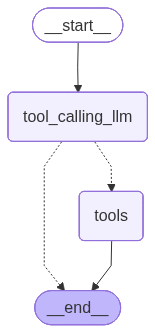

In [22]:
# Displaying the Graph after compiling

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
# Invoke

messages = graph.invoke({"messages": "1706.03762"}) # That number is a research paper number
for m in messages['messages']:
  m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (52w9z6418)
 Call ID: 52w9z6418
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [28]:
messages1 = graph.invoke({"messages": "Hi! This is Rick!!"})
for m in messages1['messages']:
  m.pretty_print()

================================ Human Message =================================

Hi! This is Rick!!
================================== Ai Message ==================================

Hello Rick. How can I assist you today?


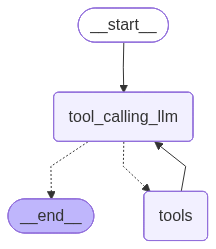

In [ ]:
# Creating another graph - giving same response (different structure) : ReAct Architecture (Reasoning + Acting/Action)

builder1 = StateGraph(State)
builder1.add_node("tool_calling_llm", tool_calling_llm)
builder1.add_node("tools", ToolNode(tools))

builder1.add_edge(START, "tool_calling_llm")
builder1.add_conditional_edges(
  "tool_calling_llm",
  # If the latest message (result) form the assistant is a tool call --> tools_confition routes to tools
  # If the latest message (result) form the assistant is NOT a tool call --> tools_confition routes to END
  tools_condition,
)
builder1.add_edge("tools", "tool_calling_llm")

graph1 = builder1.compile()

display(Image(graph1.get_graph().draw_mermaid_png()))

In [33]:
# Invoking the new graph

messages2 = graph.invoke({"messages": "What is the recent AI news and please mention the recent research papers on Quantum Computing."})
for m in messages2['messages']:
  m.pretty_print()

================================ Human Message =================================

What is the recent AI news and please mention the recent research papers on Quantum Computing.
================================== Ai Message ==================================
Tool Calls:
  arxiv (5w25108wm)
 Call ID: 5w25108wm
  Args:
    query: Quantum Computing recent research papers
  arxiv (d6cy0vf8z)
 Call ID: d6cy0vf8z
  Args:
    query: AI news recently published papers
  wikipedia (ra6cfbded)
 Call ID: ra6cfbded
  Args:
    query: Quantum Computing recent research
  wikipedia (95werr5q7)
 Call ID: 95werr5q7
  Args:
    query: AI news recent publications
  tavily_search_results_json (mc0eynfcy)
 Call ID: mc0eynfcy
  Args:
    query: recent AI news
  tavily_search_results_json (6rhzqeg06)
 Call ID: 6rhzqeg06
  Args:
    query: Quantum Computing recent research papers
================================= Tool Message =================================
Name: arxiv

Published: 2025-04-07
Title: Quantum Co